## AI - Projekt von Hendrik Stolzke
##### Studiengang: DBE1, Matrikelnummer: 821534
### Über den Datensatz einer Ebay Auktions Vorhersage
Link zum Datensatz: https://www.modelingonlineauctions.com/datasets

In [1]:
import pandas as pd

# 1. Daten laden von drei unterschiedlichen Auktionslängen (in Tagen)
data_7 = pd.read_csv("Xbox 7-day auctions.csv")
data_5 = pd.read_csv("Xbox 5-day auctions.csv")
data_3 = pd.read_csv("Xbox 3-day auctions.csv")

data_7["auction_length_days"] = 7
data_5["auction_length_days"] = 5
data_3["auction_length_days"] = 3
data = pd.concat([data_7, data_5, data_3])
data.head()

,auctionid,bid,bidtime,bidder,bidderrate,openbid,price,auction_length_days
0,8211480551,52.99,1.201505,hanna1104,94.0,49.99,311.6,7
1,8211480551,50.99,1.203843,wrufai1,90.0,49.99,311.6,7
2,8211480551,101.99,1.204433,wrufai1,90.0,49.99,311.6,7
3,8211480551,57.00,1.708437,newberryhwt,14.0,49.99,311.6,7
4,8211480551,144.48,3.089711,miloo2005,3.0,49.99,311.6,7


Features Bedeutung:

- auctionid - eindeutige Kennung einer Auktion
- bid - das von einem Bieter abgegebene Gebot
- bidtime - der Zeitpunkt (in Tagen), zu dem das Gebot seit Beginn der Auktion abgegeben wurde
- bidder - eBay-Benutzername des Bieters
- bidderrate - eBay-Feedback-Bewertung des Bieters
- openbid - das vom Verkäufer festgelegte Startgebot
- price - der Endverkaufspreis des Artikels

Hinzufügen der relativen Zeit und entfernen von Zeilen Sprüngen durch "\n" Strings in Texten:

In [2]:
# Bieter / bidder \n entfernen
data['bidder'] = data['bidder'].replace('\n', '', regex=True)
data["relative_time"] = data["bidtime"] / data["auction_length_days"]

Datenbeschreibung (Statistik):

In [3]:
# Statische Übersicht über die Features
data.describe()

,auctionid,bid,bidtime,bidderrate,openbid,price,auction_length_days,relative_time
count,2.811000e+03,2811.000000,2811.000000,2800.000000,2811.000000,2811.000000,2811.000000,2811.000000
mean,8.213359e+09,85.245037,4.349047,30.352500,25.483404,143.857780,5.927784,0.729360
std,1.014407e+06,60.171630,2.390022,131.380035,32.676305,73.059184,1.606519,0.330887
min,8.211481e+09,0.010000,0.000567,-1.000000,0.010000,28.000000,3.000000,0.000081
25%,8.212610e+09,44.000000,2.380810,0.000000,0.990000,105.000000,5.000000,0.509211
50%,8.213067e+09,80.000000,4.900775,4.000000,9.990000,127.500000,7.000000,0.909942
75%,8.214330e+09,112.510000,6.788727,18.000000,49.990000,152.500000,7.000000,0.987840
max,8.215611e+09,501.770000,6.999977,2736.000000,175.000000,501.770000,7.000000,0.999997


In [4]:
print(f"Anzahl Zeilen: {len(data)}")
print(f"Anzahl Auktionen zum Erwerb jeweils einer XBOX: {data['auctionid'].nunique()}")

Anzahl Zeilen: 2811
Anzahl Auktionen zum Erwerb jeweils einer XBOX: 149


Analyse Top 50 Auktionsgewinner:

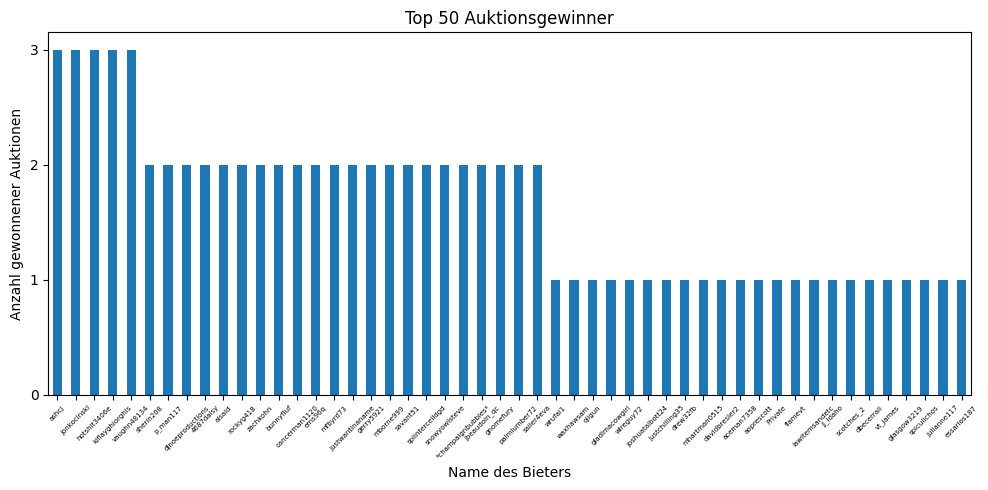

In [5]:
import matplotlib.pyplot as plt
winner_counts = data[data['bid'] == data['price']]["bidder"].value_counts().head(50)
# print(winner_counts)

plt.figure(figsize=(10, 5))
winner_counts.plot(kind="bar")
plt.yticks(range(0, winner_counts.max() + 1, 1))
plt.title("Top 50 Auktionsgewinner")
plt.xlabel("Name des Bieters")
plt.ylabel("Anzahl gewonnener Auktionen")
plt.xticks(rotation=45, fontsize=5)
plt.tight_layout()
plt.show()

Anzahl Gebote und Gebotshöhe über Zeit (in Tagen):

Bei Begin und Ende der 3, 5 und 7 Tage Auktionen gibt es jeweils einen starken Anstieg der Gebote, was auf die erhöhte Aktivität der Bieter zu diesen Zeitpunkten hinweist.


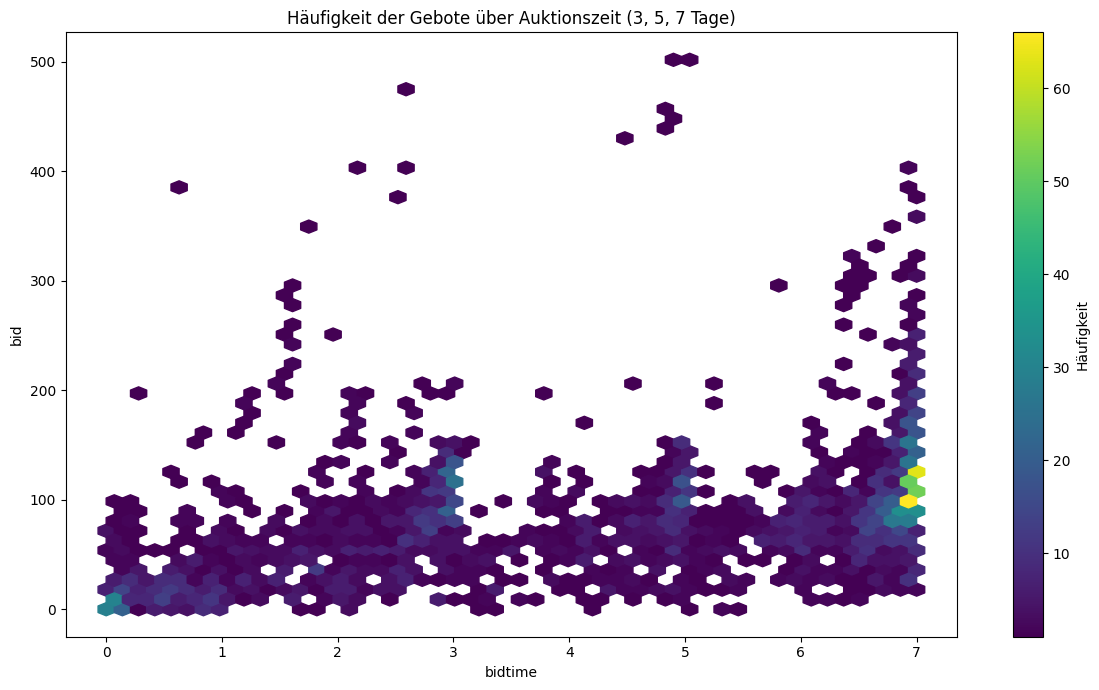

In [6]:
print("Bei Begin und Ende der 3, 5 und 7 Tage Auktionen gibt es jeweils einen starken Anstieg der Gebote, was auf die erhöhte Aktivität der Bieter zu diesen Zeitpunkten hinweist.")

plt.figure(figsize=(12, 7))
hb = plt.hexbin(data["bidtime"], data["bid"], gridsize=50, cmap="viridis", mincnt=1)
plt.colorbar(hb, label="Häufigkeit")
plt.xlabel("bidtime")
plt.ylabel("bid")
plt.title("Häufigkeit der Gebote über Auktionszeit (3, 5, 7 Tage)")
plt.tight_layout()
plt.show()

Anzahl Gebote und Gebotshöhe über Zeit (in Prozent):

Die meisten Gebote konzentrieren sich auf die Endphase der Auktionen, was auf eine erhöhte Bieteraktivität zu diesen Zeitpunkten hinweist. Es gibt auch eine moderate Anzahl von Geboten in der Mitte der Auktion, aber die Spitze sind deutlich am Ende zu erkennen.


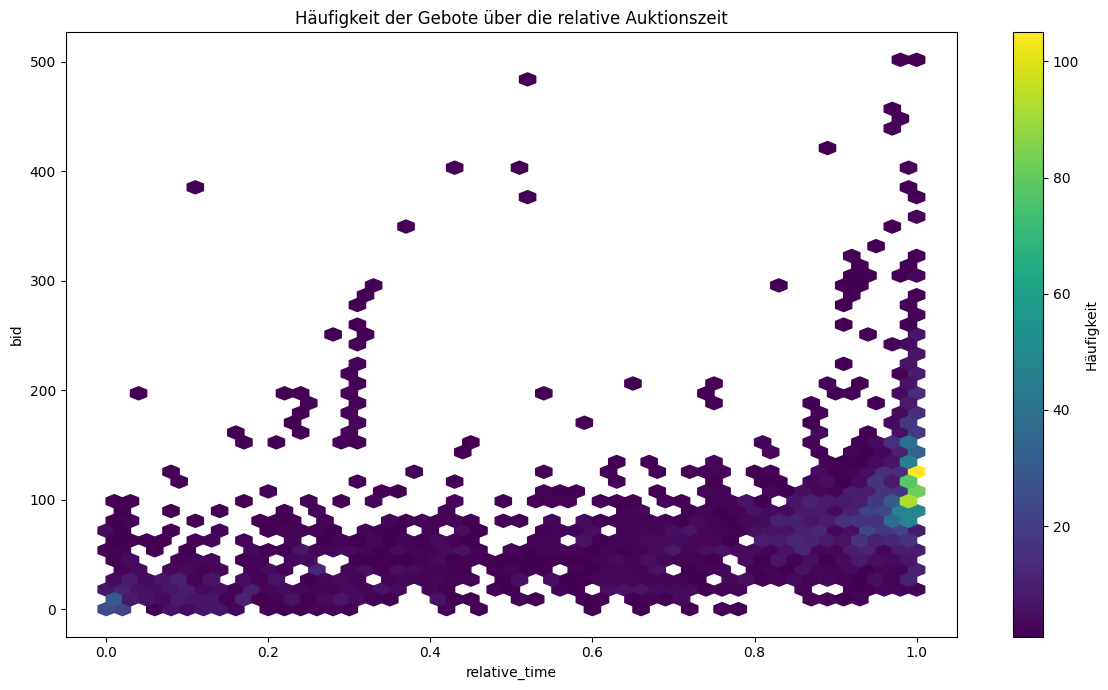

In [7]:
print("Die meisten Gebote konzentrieren sich auf die Endphase der Auktionen, was auf eine erhöhte Bieteraktivität zu diesen Zeitpunkten hinweist. Es gibt auch eine moderate Anzahl von Geboten in der Mitte der Auktion, aber die Spitze sind deutlich am Ende zu erkennen.")
plt.figure(figsize=(12, 7))
hb = plt.hexbin(data["relative_time"], data["bid"], gridsize=50, cmap="viridis", mincnt=1)
plt.colorbar(hb, label="Häufigkeit")
plt.xlabel("relative_time")
plt.ylabel("bid")
plt.title("Häufigkeit der Gebote über die relative Auktionszeit")
plt.tight_layout()
plt.show()

Kombi-Diagramme zur Visualisierung von Feature Verteilungen:

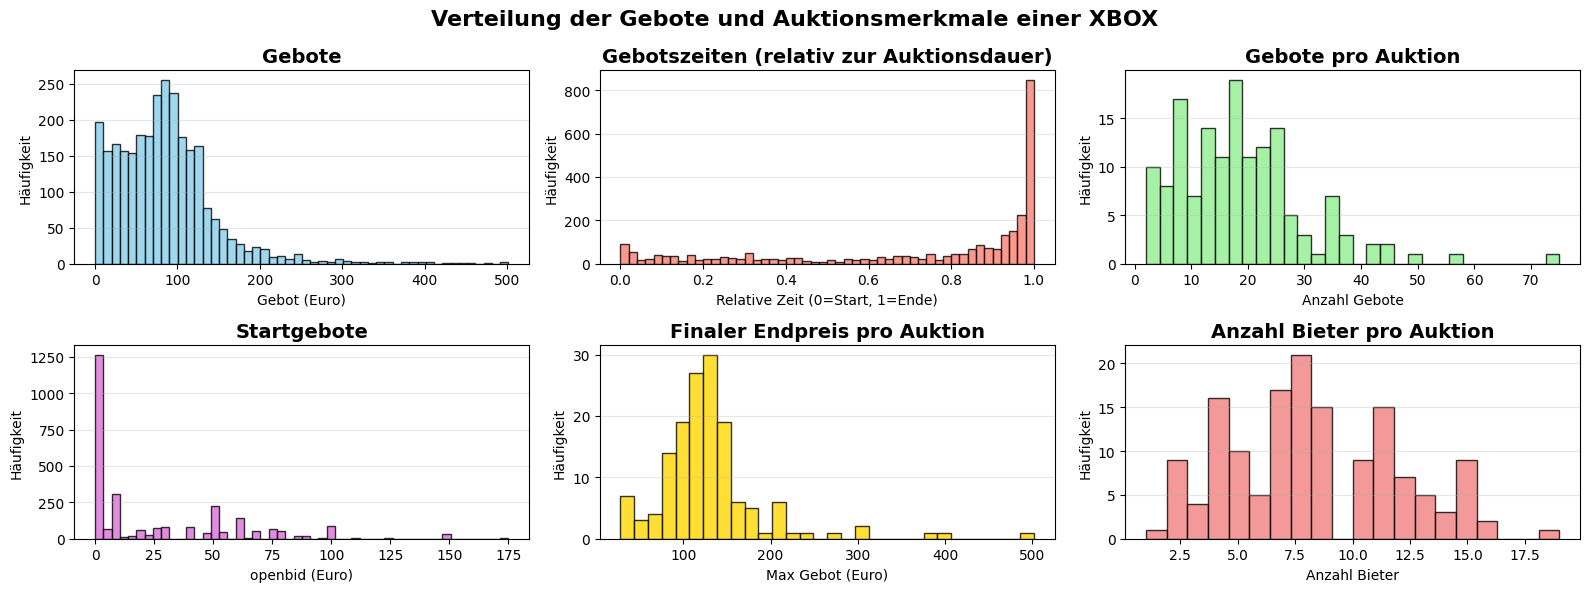

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(16, 6))
fig.suptitle("Verteilung der Gebote und Auktionsmerkmale einer XBOX", fontsize=16, fontweight='bold')
# 1Gebote insgesamt
axes[0,0].hist(data["bid"], bins=50, color="skyblue", edgecolor="black", alpha=0.8)
axes[0,0].set_title("Gebote", fontsize=14, fontweight='bold')
axes[0,0].set_xlabel("Gebot (Euro)")
axes[0,0].set_ylabel("Häufigkeit")
axes[0,0].grid(axis='y', alpha=0.3)

# Gebotszeiten
axes[0,1].hist(data["relative_time"], bins=50, color="salmon", edgecolor="black", alpha=0.8)
axes[0,1].set_title("Gebotszeiten (relativ zur Auktionsdauer)", fontsize=14, fontweight='bold')
axes[0,1].set_xlabel("Relative Zeit (0=Start, 1=Ende)")
axes[0,1].set_ylabel("Häufigkeit")
axes[0,1].grid(axis='y', alpha=0.3)

# Anzahl Gebote pro Auktion
auction_bid_counts = data.groupby("auctionid").size()
axes[0,2].hist(auction_bid_counts, bins=30, color="lightgreen", edgecolor="black", alpha=0.8)
axes[0,2].set_title("Gebote pro Auktion", fontsize=14, fontweight='bold')
axes[0,2].set_xlabel("Anzahl Gebote")
axes[0,2].set_ylabel("Häufigkeit")
axes[0,2].grid(axis='y', alpha=0.3)

# Startgebote
axes[1,0].hist(data["openbid"], bins=50, color="orchid", edgecolor="black", alpha=0.8)
axes[1,0].set_title("Startgebote", fontsize=14, fontweight='bold')
axes[1,0].set_xlabel("openbid (Euro)")
axes[1,0].set_ylabel("Häufigkeit")
axes[1,0].grid(axis='y', alpha=0.3)

# Maximalgebot pro Auktion
max_bid_per_auction = data.groupby("auctionid")["bid"].max()
axes[1,1].hist(max_bid_per_auction, bins=30, color="gold", edgecolor="black", alpha=0.8)
axes[1,1].set_title("Finaler Endpreis pro Auktion", fontsize=14, fontweight='bold')
axes[1,1].set_xlabel("Max Gebot (Euro)")
axes[1,1].set_ylabel("Häufigkeit")
axes[1,1].grid(axis='y', alpha=0.3)

# Anzahl Bieter pro Auktion
num_bidders_per_auction = data.groupby("auctionid")["bidder"].nunique()
axes[1,2].hist(num_bidders_per_auction, bins=20, color="lightcoral", edgecolor="black", alpha=0.8)
axes[1,2].set_title("Anzahl Bieter pro Auktion", fontsize=14, fontweight='bold')
axes[1,2].set_xlabel("Anzahl Bieter")
axes[1,2].set_ylabel("Häufigkeit")
axes[1,2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Erstellung von Features:

In [9]:
import pandas as pd

# 2. Feature Engineering
# Sortieren nach Auktionen und Gebotszeit
data = data.sort_values(["auctionid", "bidtime"]).reset_index(drop=True)
# data = data[(data["bid"] > 0) & (data["bid"] < 150)]  # Ausreißer entfernen

# Historien-Features berechnen
features_list = []

# Für jede Auktion die historischen Features berechnen
for auction_id, group in data.groupby("auctionid"):
    # Kopie der Gruppe erstellen, um die Originaldaten nicht zu verändern
    group = group.copy()
    # cum_max_bid: Das bisher höchste Gebot in der Auktion
    group["cum_max_bid"] = group["bid"].cummax()
    # cum_avg_bid: Der Durchschnitt aller bisherigen Gebote in der Auktion
    group["cum_avg_bid"] = group["bid"].expanding().mean()
    # num_bids_so_far: Die Anzahl der Gebote, die bisher in der Auktion abgegeben wurden
    group["num_bids_so_far"] = range(1, len(group)+1)
    unique_bidders = set()
    num_unique = []
    for bidder in group["bidder"]:
        unique_bidders.add(bidder)
        num_unique.append(len(unique_bidders))
    # num_unique_bidders_so_far: Die Anzahl der einzigartigen Bieter, die bisher in der Auktion geboten haben
    group["num_unique_bidders_so_far"] = num_unique
    # relative_time: Die relative Zeit des Gebots in Bezug auf die Auktionsdauer (0 = Start, 1 = Ende)
    group["relative_time"] = group["bidtime"] / group["auction_length_days"]
    # target_price: Der Endpreis der Auktion (gleicher Wert für alle Zeilen einer Auktion)
    group["target_price"] = group["price"].iloc[0]  # Endpreis für jede Zeile
    features_list.append(group)

features = pd.concat(features_list).reset_index(drop=True)

# Features & Target definieren
feature_cols = [
    "auctionid",
    "bidtime",
    "cum_max_bid",
    "cum_avg_bid",
    "num_bids_so_far",
    "num_unique_bidders_so_far",
    "relative_time",
    "bidderrate",
    "bid",
    "openbid",
    "auction_length_days"
]
features.head()

,auctionid,bid,bidtime,bidder,bidderrate,openbid,price,auction_length_days,relative_time,cum_max_bid,cum_avg_bid,num_bids_so_far,num_unique_bidders_so_far,target_price
0,8211480551,52.99,1.201505,hanna1104,94.0,49.99,311.6,7,0.171644,52.99,52.990000,1,1,311.6
1,8211480551,50.99,1.203843,wrufai1,90.0,49.99,311.6,7,0.171978,52.99,51.990000,2,2,311.6
2,8211480551,101.99,1.204433,wrufai1,90.0,49.99,311.6,7,0.172062,101.99,68.656667,3,2,311.6
3,8211480551,57.00,1.708437,newberryhwt,14.0,49.99,311.6,7,0.244062,101.99,65.742500,4,3,311.6
4,8211480551,144.48,3.089711,miloo2005,3.0,49.99,311.6,7,0.441387,144.48,81.490000,5,4,311.6


Datenaufteilung in Trainings- und Testdaten:

In [10]:
from sklearn.model_selection import train_test_split

# 3. Daten vorbereiten
X = features[feature_cols]
y = features["target_price"]


# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True,
)
# # Validierungsdaten werden wegen der Cross-Validation der Gridsearch nicht benötigt!
# X_validation, X_test, y_validation, y_test = train_test_split(
#     X_test, y_test, test_size=0.5, random_state=42, shuffle=True,
# )
print(f"Trainingsdaten: {X_train.shape[0]} | Testdaten: {X_test.shape[0]}")
X.head()

Trainingsdaten: 2248 | Testdaten: 563


,auctionid,bidtime,cum_max_bid,cum_avg_bid,num_bids_so_far,num_unique_bidders_so_far,relative_time,bidderrate,bid,openbid,auction_length_days
0,8211480551,1.201505,52.99,52.990000,1,1,0.171644,94.0,52.99,49.99,7
1,8211480551,1.203843,52.99,51.990000,2,2,0.171978,90.0,50.99,49.99,7
2,8211480551,1.204433,101.99,68.656667,3,2,0.172062,90.0,101.99,49.99,7
3,8211480551,1.708437,101.99,65.742500,4,3,0.244062,14.0,57.00,49.99,7
4,8211480551,3.089711,144.48,81.490000,5,4,0.441387,3.0,144.48,49.99,7


Training eines Random Forest Regressions Algorithmus (Entscheidungsbaum) mit GridsearchCV (Cross Validation):

In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Modell
rf = RandomForestRegressor(random_state=42)
param_grid = {
    'n_estimators': [100, 200, 500, 1000, 2000],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# Grid Search mit 5-facher Cross-Validation und MAE als Bewertungsmetrik
# Daher keine Validierungsdaten nötig, da die Cross-Validation die Daten in Trainings- und Validierungssets aufteilt
grid_search = GridSearchCV(
    estimator=rf, # Modell
    param_grid=param_grid, # Hyperparameter-Raster
    cv=5, # 5-fache Cross-Validation
    scoring='neg_mean_absolute_error',  # MAE negativ, da GridSearchCV höhere Werte bevorzugt
    n_jobs=-1, # Alle verfügbaren CPU-Kerne nutzen
    verbose=2 # Fortschrittsanzeige
)
grid_search.fit(X_train, y_train)

print("Beste Parameter:")
print(grid_search.best_params_)
print("Bestes Ergebnis (MAE):")
print(-grid_search.best_score_)  # -MAE wieder positiv machen

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Beste Parameter:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Bestes Ergebnis (MAE):
11.927939688196


##### Gridsearch
Die GridSearchCV sucht systematisch alle Kombinationen der angegebenen Hyperparameter und bewertet jede Kombination anhand eines festgelegten Scoring-Kriteriums, um die beste Modellkonfiguration zu finden.

##### Cross Validation (CV)
Bei 5-Fold Cross-Validation wird der Datensatz in 5 gleich große Teile aufgeteilt. In jedem Durchlauf wird ein anderer Teil als Validierungsset verwendet, während die restlichen 4 Teile das Trainingsset bilden. Das Trainingsset besteht dabei jeweils aus etwa 4/5 der Daten (hier ca. 1798 von 2248 Datenpunkten), das Validierungsset aus etwa 1/5 (ca. 450 Datenpunkte).
Dieser Prozess wird 5-mal wiederholt, sodass jedes Teil einmal als Validierungsset dient.

Speichern des trainierten Modells:

In [12]:
import joblib

# Bestes Modell aus der Grid Search extrahieren
best_model = grid_search.best_estimator_

# Modell in der .pkl-Datei speichern
joblib.dump(best_model, 'rf_model.pkl')

['rf_model.pkl']

Laden des gespeicherten Modells: 

In [13]:
import joblib

# Modell aus der .pkl-Datei laden
model = joblib.load('rf_model.pkl')
model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

Vorhersage und Berechnung der Abweichung zum Testdatensatz:

Mean Absolute Error: 10.967847424511564
Mit einer durchschnittlichen Abweichung von 10.97 Euro zeigt das Modell eine gute Leistung, wobei es besser sein könnte.
Das Modell hat Schwierigkeiten bei Auktionen mit hohen Geboten und schätzt diese tendenziell zu niedrig ein, während es bei niedrigeren Geboten oft zu hohe Vorhersagen macht.
Bei 150 Euro Geboten sind die Gebote im mittel ausgeglichen, aber die Unsicherheit ist trotzdem hoch.


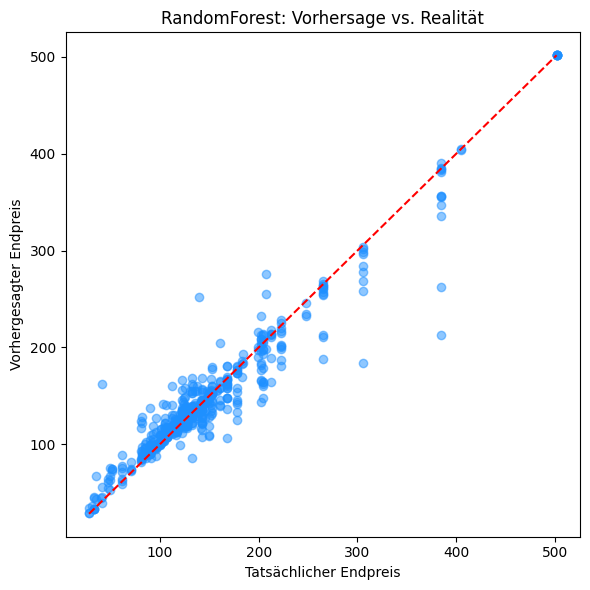

In [14]:
from sklearn.metrics import mean_absolute_error

# 5. Vorhersage
y_pred = model.predict(X_test)

# 6. Evaluation
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)
print("Mit einer durchschnittlichen Abweichung von {:.2f} Euro zeigt das Modell eine gute Leistung, wobei es besser sein könnte.".format(mae))
print("Das Modell hat Schwierigkeiten bei Auktionen mit hohen Geboten und schätzt diese tendenziell zu niedrig ein, während es bei niedrigeren Geboten oft zu hohe Vorhersagen macht.")
print("Bei 150 Euro Geboten sind die Gebote im mittel ausgeglichen, aber die Unsicherheit ist trotzdem hoch.")

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5, color="dodgerblue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Tatsächlicher Endpreis")
plt.ylabel("Vorhergesagter Endpreis")
plt.title("RandomForest: Vorhersage vs. Realität")
plt.tight_layout()
plt.show()

In [15]:
# 7. Beispiel Vorhersage
print("Testdaten Vorhersagen (erste 10):")
for i in range(10):
    print(f"Real: {y_test.iloc[i]:.2f} | Predicted: {y_pred[i]:.2f}")

Testdaten Vorhersagen (erste 10):
Real: 122.50 | Predicted: 135.29
Real: 106.50 | Predicted: 111.05
Real: 265.00 | Predicted: 211.10
Real: 405.00 | Predicted: 404.80
Real: 202.00 | Predicted: 212.79
Real: 122.50 | Predicted: 124.38
Real: 202.50 | Predicted: 164.93
Real: 141.00 | Predicted: 122.58
Real: 132.50 | Predicted: 132.30
Real: 116.50 | Predicted: 109.07


Feature Wichtigkeit für den Endpreis (Zielvariable):

C:\Users\hendr\AppData\Local\Temp\ipykernel_24176\630151472.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance", y="feature", data=feat_imp, palette="viridis")


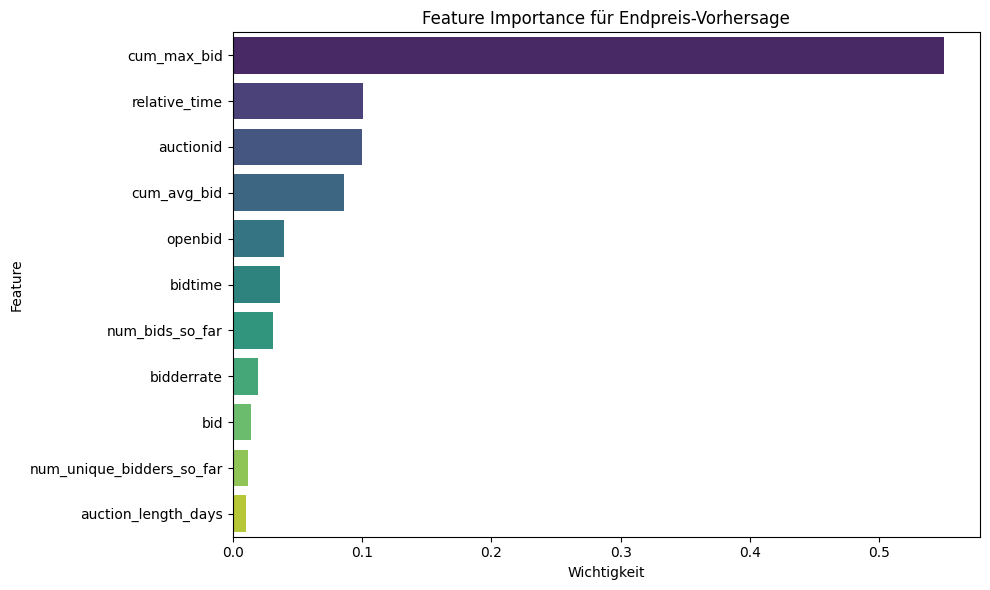

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 8. Feature Importance und Feature Names auslesen
importances = model.feature_importances_
feature_names = feature_cols

feat_imp = pd.DataFrame({"feature": feature_names, "importance": importances})
feat_imp = feat_imp.sort_values(by="importance", ascending=False)

# Plotten
plt.figure(figsize=(10,6))
sns.barplot(x="importance", y="feature", data=feat_imp, palette="viridis")
plt.title("Feature Importance für Endpreis-Vorhersage")
plt.xlabel("Wichtigkeit")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Zeitlicher Vorhersage Verlauf während einer Auktion:

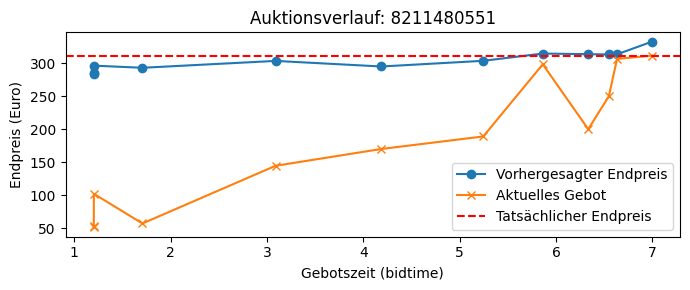

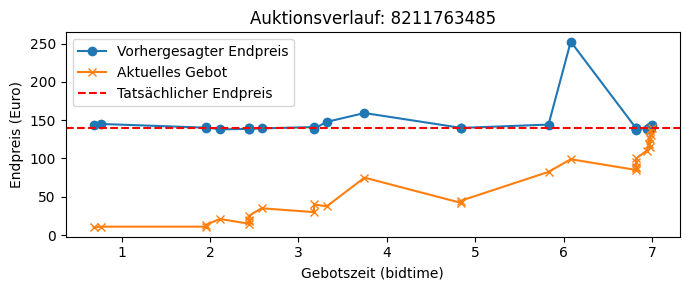

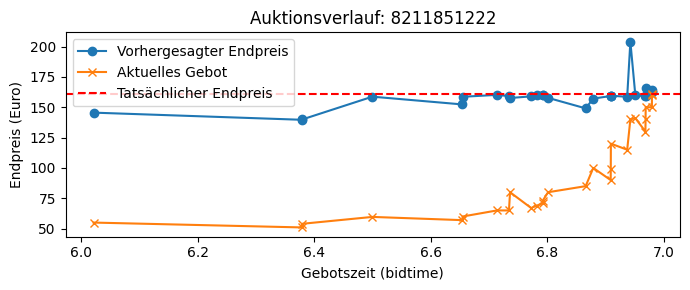

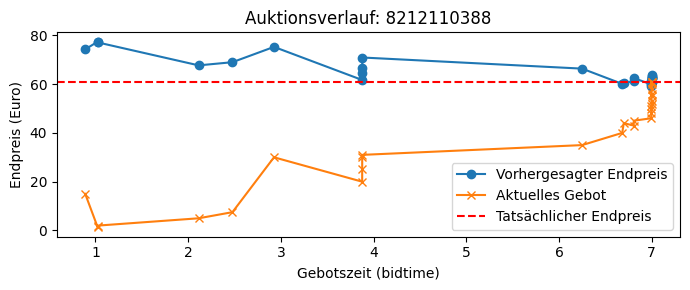

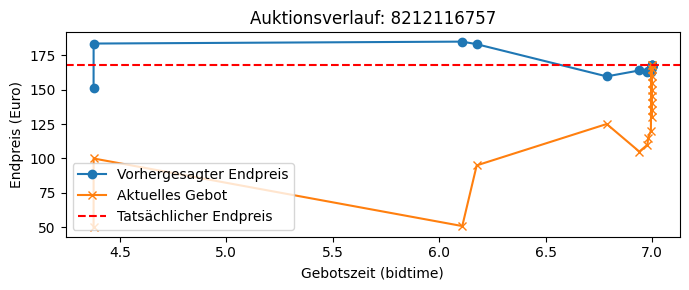

In [ ]:
# 9. Beispielhafte Vorhersage für den Verlauf von Auktionen
for auction_id_example in features["auctionid"].unique()[:5]:  # Beispiel für die ersten 5 Auktionen
    # Auswahl der Daten für die aktuelle Auktion
    auction_data = features[features["auctionid"] == auction_id_example]

    # Vorhersage für die aktuelle Auktion
    X_example = auction_data[feature_cols]
    y_example_pred = model.predict(X_example)

    plt.figure(figsize=(7,3))
    plt.plot(auction_data["bidtime"], y_example_pred, marker="o", label="Vorhergesagter Endpreis")
    plt.plot(auction_data["bidtime"], auction_data["bid"], marker="x",label="Aktuelles Gebot")
    plt.axhline(auction_data["price"].iloc[0], color="r", linestyle="--", label="Tatsächlicher Endpreis")
    plt.xlabel("Gebotszeit (bidtime)")
    plt.ylabel("Endpreis (Euro)")
    plt.title(f"Auktionsverlauf: {auction_id_example}")
    plt.legend()
    plt.tight_layout()
    plt.show()

Analyse der Residuen (Abweichungen von Vorhersage zur Grundwahrheit):

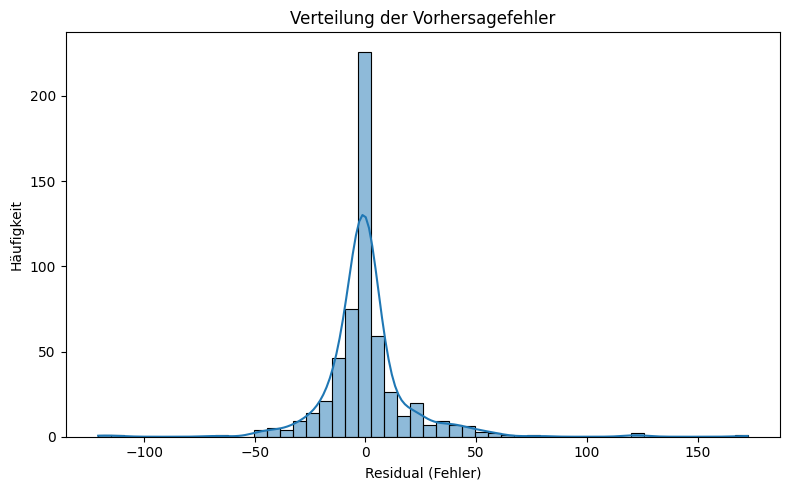

In [ ]:
# 10. Analyse der Vorhersagefehler
residuals = y_test - y_pred
plt.figure(figsize=(8,5))
sns.histplot(residuals, bins=50, kde=True)
plt.xlabel("Residual (Fehler)")
plt.ylabel("Häufigkeit")
plt.title("Verteilung der Vorhersagefehler")
plt.tight_layout()
plt.show()